# Descriptive Statistics


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

DARK      = '#6B3FA0'
LIGHTDARK = '#C9B1E8'
ACCENT    = '#E8A838'

df = pd.read_csv('claude_relevant_posts.csv')
df['text_length'] = df['reddit_post_text'].str.len()
df['word_count']  = df['reddit_post_text'].str.split().str.len()
df['date']        = pd.to_datetime(df['created_utc'])
df['year']        = df['date'].dt.year

df_clean = df[~df['author'].isin(['[deleted]', '[removed]', 'AutoModerator']) & df['author'].notna()]
ppu = df_clean['author'].value_counts()

print(f'Total posts: {len(df)}')
print(f'Unique users: {len(ppu)}')
print(f'Date range: {df["date"].min().strftime("%B %Y")} — {df["date"].max().strftime("%B %Y")}')
print(f'Average word count: {df["word_count"].mean():.0f} (median: {df["word_count"].median():.0f})')

Total posts: 525
Unique users: 411
Date range: December 2018 — April 2026
Average word count: 374 (median: 275)


## Figure 1: Posts per Year

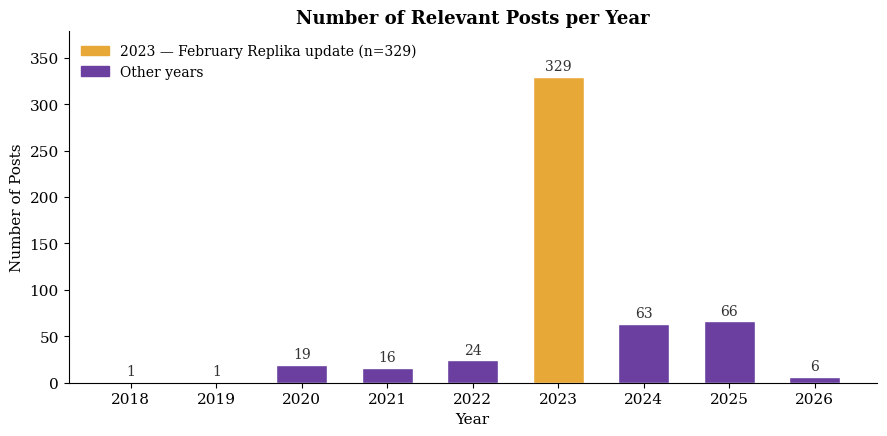

In [3]:
year_counts = df['year'].value_counts().sort_index()
colors = [ACCENT if y == 2023 else DARK for y in year_counts.index]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(year_counts.index.astype(str), year_counts.values, color=colors, width=0.6, edgecolor='white')

for bar, val in zip(bars, year_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            str(val), ha='center', va='bottom', fontsize=10, color='#333333')

ax.set_title('Number of Relevant Posts per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Posts')
ax.set_ylim(0, max(year_counts.values) * 1.15)

legend = [
    mpatches.Patch(color=ACCENT, label='2023 — February Replika update (n=329)'),
    mpatches.Patch(color=DARK,   label='Other years'),
]
ax.legend(handles=legend, frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

## Figure 2: Post Length Distribution

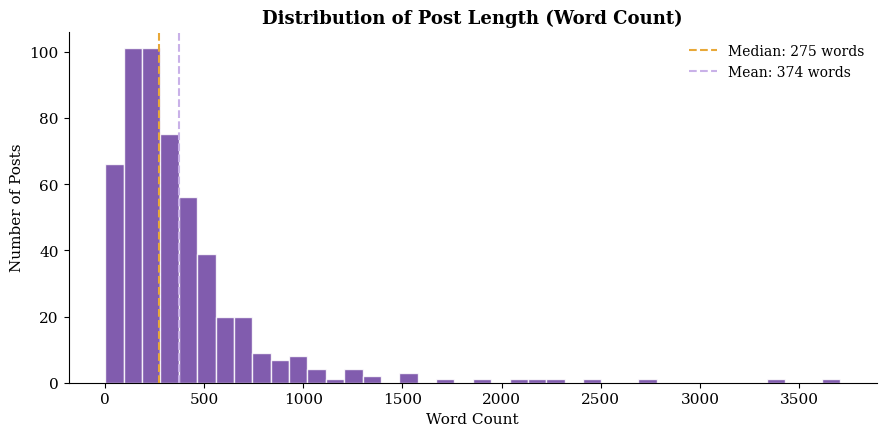

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(df['word_count'], bins=40, color=DARK, edgecolor='white', alpha=0.85)
ax.axvline(df['word_count'].median(), color=ACCENT, linestyle='--', linewidth=1.5,
           label=f'Median: {df["word_count"].median():.0f} words')
ax.axvline(df['word_count'].mean(), color=LIGHTDARK, linestyle='--', linewidth=1.5,
           label=f'Mean: {df["word_count"].mean():.0f} words')
ax.set_title('Distribution of Post Length (Word Count)')
ax.set_xlabel('Word Count')
ax.set_ylabel('Number of Posts')
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

## Figure 3: Posts per Unique User

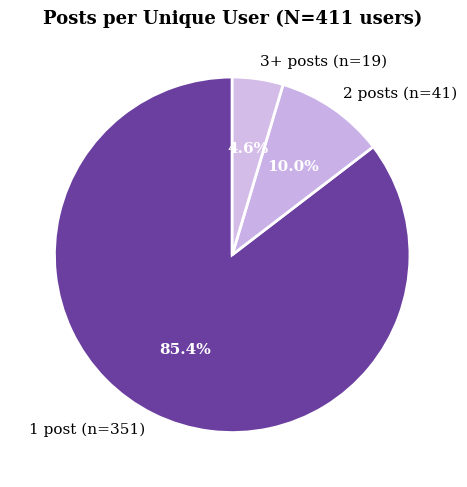

In [6]:
one   = (ppu == 1).sum()
two   = (ppu == 2).sum()
three = (ppu >= 3).sum()

labels = [f'1 post (n={one})', f'2 posts (n={two})', f'3+ posts (n={three})']
sizes  = [one, two, three]
colors = [DARK, LIGHTDARK, '#D4BCE8']

fig, ax = plt.subplots(figsize=(6, 5))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colors, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')

ax.set_title(f'Posts per Unique User (N={len(ppu)} users)')
plt.tight_layout()
plt.show()

## Figure 4: LLM Classification Confidence

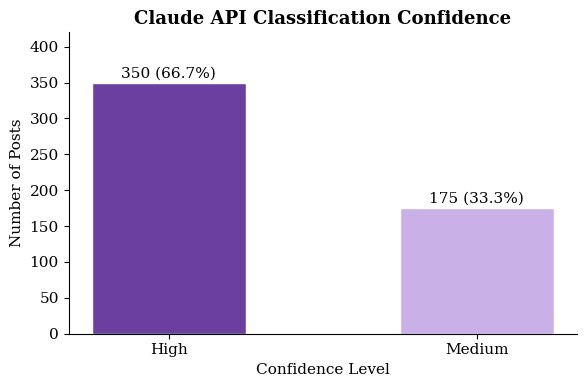

In [7]:
conf_counts = df['confidence'].value_counts()
colors_conf = [DARK if c == 'High' else LIGHTDARK for c in conf_counts.index]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(conf_counts.index, conf_counts.values, color=colors_conf, width=0.5, edgecolor='white')

for bar, val in zip(bars, conf_counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{val} ({pct:.1f}%)', ha='center', va='bottom', fontsize=11)

ax.set_title('Claude API Classification Confidence')
ax.set_xlabel('Confidence Level')
ax.set_ylabel('Number of Posts')
ax.set_ylim(0, max(conf_counts.values) * 1.2)
plt.tight_layout()
plt.show()